In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
df = pd.read_csv("../data/processed_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1486, 5)

First 5 rows:


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,675.324158,683.152852,673.490062,679.081936,14004468
2020-01-02,686.821228,689.348791,676.397899,676.397899,17710316
2020-01-03,687.648804,689.661895,681.318729,685.792252,20984698
2020-01-06,671.700623,683.510705,670.134872,679.976657,24519177
2020-01-07,682.034546,686.463335,677.068889,679.529321,16683622


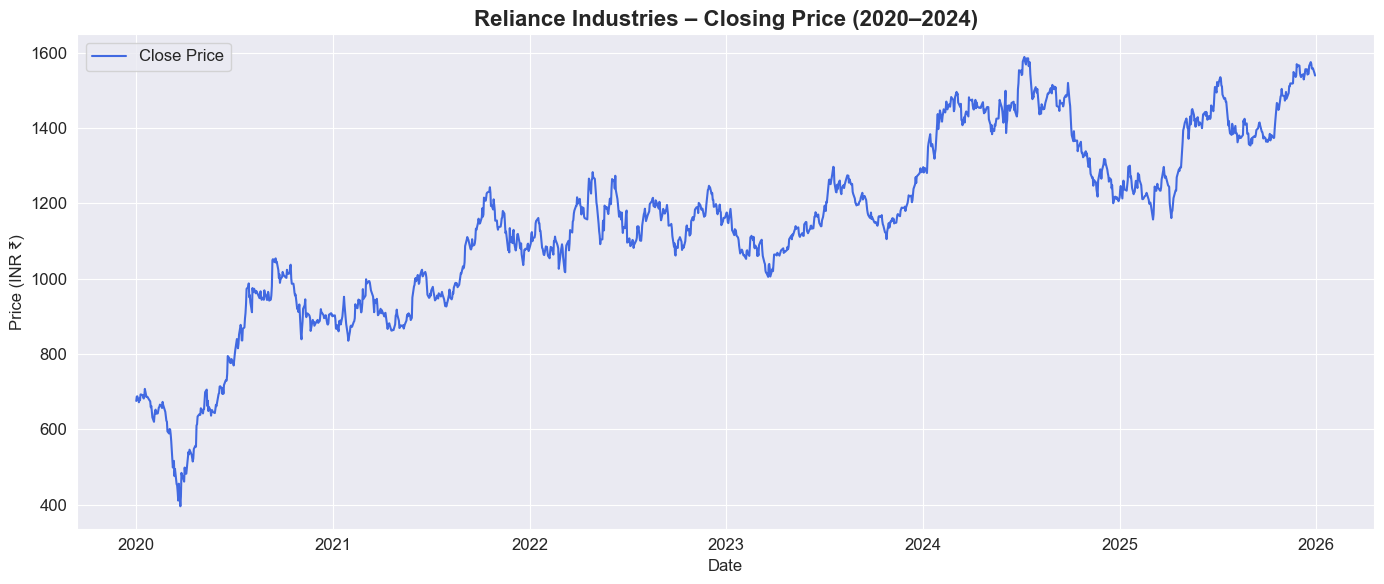

Chart 1 saved!


In [3]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='royalblue', linewidth=1.5, label='Close Price')
plt.title('Reliance Industries – Closing Price (2020–2024)', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (INR ₹)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/chart1_closing_price.png', dpi=150)
plt.show()
print("Chart 1 saved!")

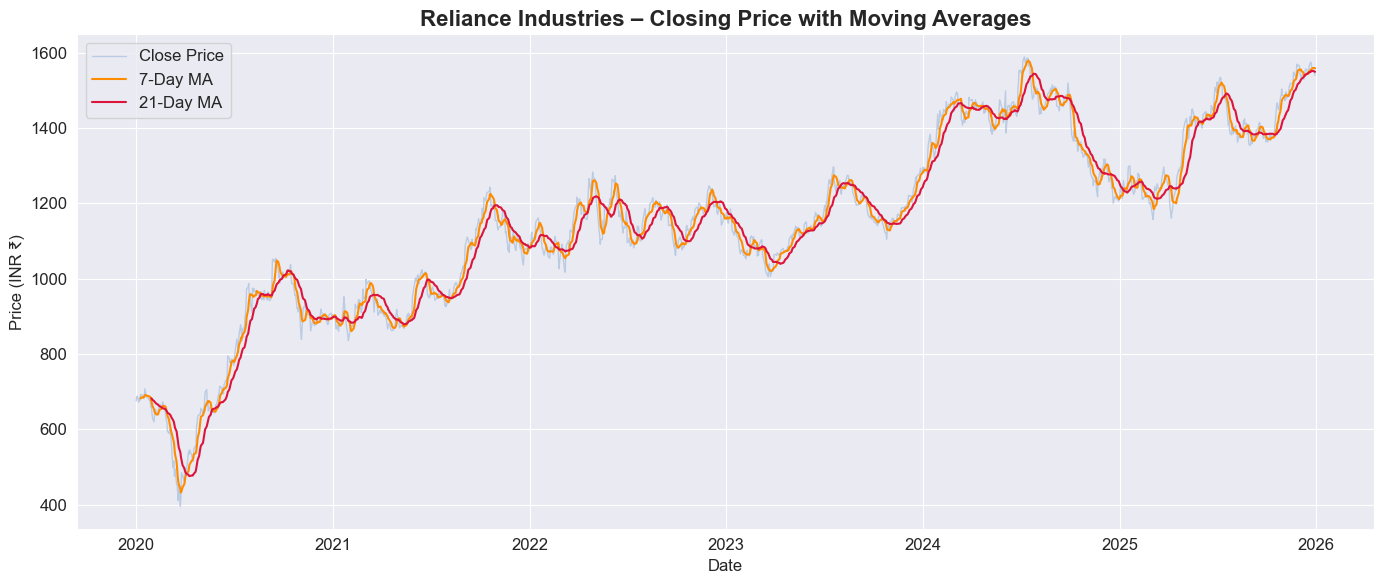

Chart 2 saved!


In [4]:
# Calculate moving averages
df['MA7']  = df['Close'].rolling(window=7).mean()
df['MA21'] = df['Close'].rolling(window=21).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='lightsteelblue', linewidth=1,   label='Close Price', alpha=0.8)
plt.plot(df.index, df['MA7'],   color='darkorange',     linewidth=1.5, label='7-Day MA')
plt.plot(df.index, df['MA21'],  color='crimson',        linewidth=1.5, label='21-Day MA')
plt.title('Reliance Industries – Closing Price with Moving Averages', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (INR ₹)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/chart2_moving_averages.png', dpi=150)
plt.show()
print("Chart 2 saved!")

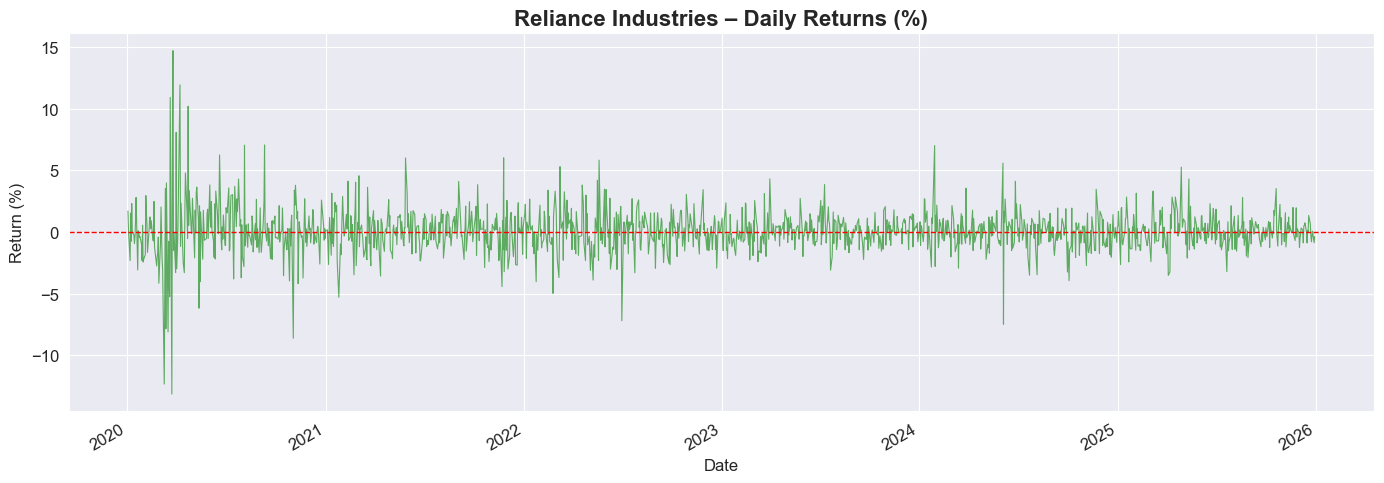

Average daily return : 0.0713%
Max gain in a day    : 14.72%
Max loss in a day    : -13.15%
Std deviation        : 1.7809%


In [5]:
df['Daily_Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(14, 5))
df['Daily_Return'].plot(kind='line', color='green', alpha=0.6, linewidth=0.8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Reliance Industries – Daily Returns (%)', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.tight_layout()
plt.savefig('../data/chart3_daily_returns.png', dpi=150)
plt.show()

print(f"Average daily return : {df['Daily_Return'].mean():.4f}%")
print(f"Max gain in a day    : {df['Daily_Return'].max():.2f}%")
print(f"Max loss in a day    : {df['Daily_Return'].min():.2f}%")
print(f"Std deviation        : {df['Daily_Return'].std():.4f}%")

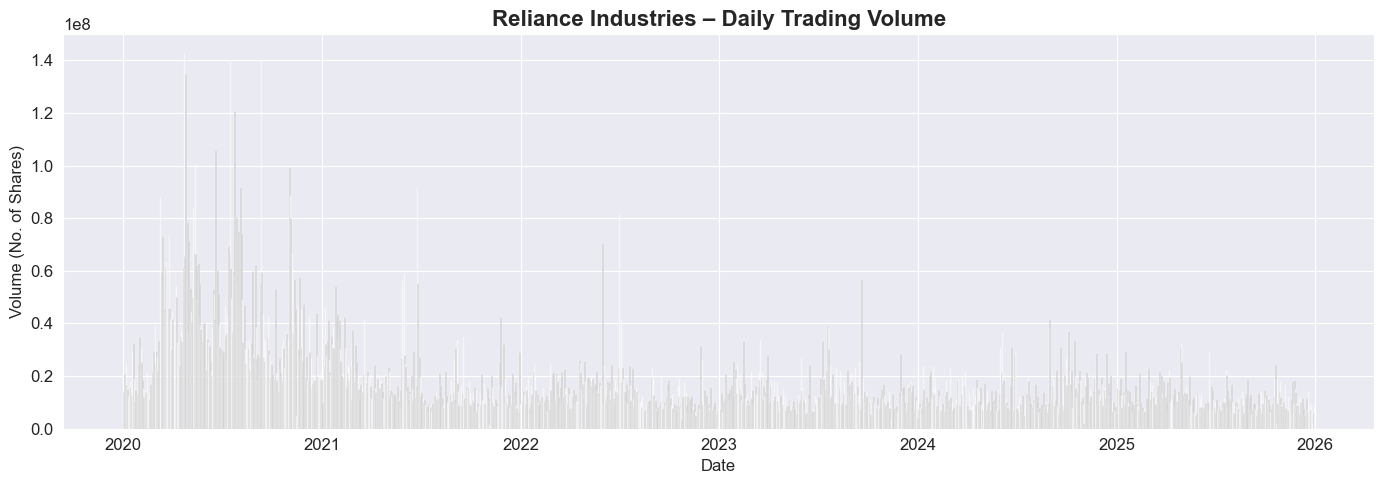

Chart 4 saved!


In [15]:
plt.figure(figsize=(14, 5))
plt.bar(df.index, df['Volume'], color='black', alpha=0.6, width=1)
plt.title('Reliance Industries – Daily Trading Volume', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volume (No. of Shares)')
plt.tight_layout()
plt.savefig('../data/chart4_volume.png', dpi=150)
plt.show()
print("Chart 4 saved!")

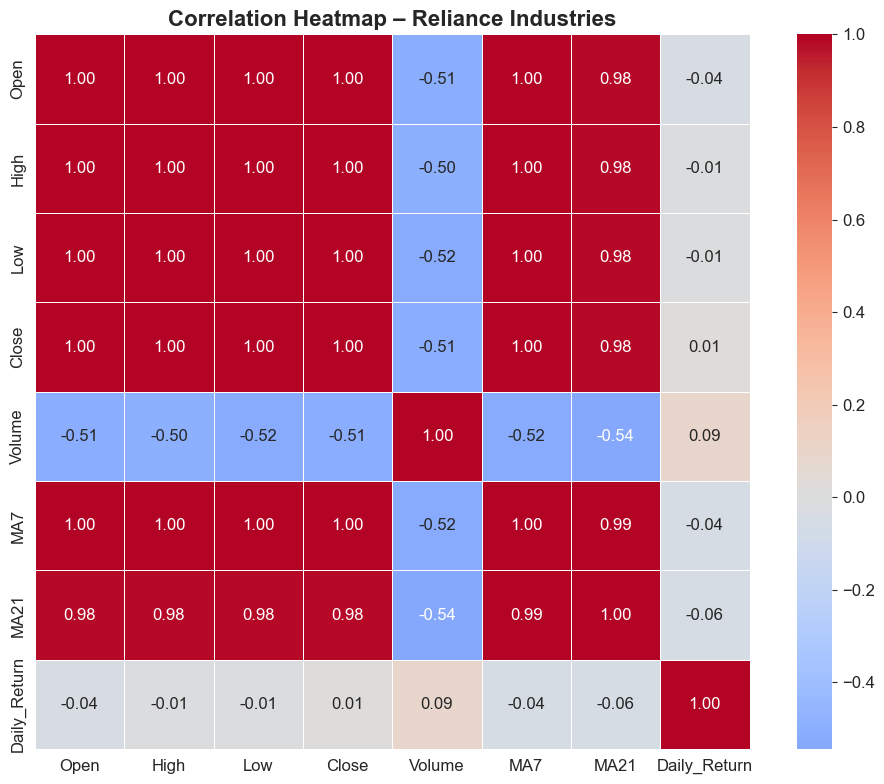

Chart 5 saved!


In [16]:
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA21', 'Daily_Return']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap – Reliance Industries', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/chart5_correlation_heatmap.png', dpi=150)
plt.show()
print("Chart 5 saved!")

In [17]:
# Last 90 trading days
df_candle = df.last('90D').reset_index()

fig = go.Figure(data=[go.Candlestick(
    x=df_candle['Date'],
    open=df_candle['Open'],
    high=df_candle['High'],
    low=df_candle['Low'],
    close=df_candle['Close'],
    increasing_line_color='green',
    decreasing_line_color='red'
)])

fig.update_layout(
    title='Reliance Industries – Candlestick Chart (Last 90 Days)',
    xaxis_title='Date',
    yaxis_title='Price (INR ₹)',
    xaxis_rangeslider_visible=False,
    template='plotly_dark',
    height=500
)
fig.show()
print("Candlestick chart rendered!")

Candlestick chart rendered!


In [19]:
print("=" * 50)
print("EDA SUMMARY — RELIANCE.NS (2020–2024)")
print("=" * 50)
print(f"Total trading days    : {len(df)}")
print(f"Starting price        : ₹{df['Close'].iloc[0]:.2f}")
print(f"Ending price          : ₹{df['Close'].iloc[-1]:.2f}")
print(f"Highest price         : ₹{df['Close'].max():.2f}")
print(f"Lowest price          : ₹{df['Close'].min():.2f}")
print(f"Average closing price : ₹{df['Close'].mean():.2f}")
print(f"Average daily return  : {df['Daily_Return'].mean():.4f}%")
print(f"Max gain in a day     : {df['Daily_Return'].max():.2f}%")
print(f"Max loss in a day     : {df['Daily_Return'].min():.2f}%")
print(f"Most volatile year    : {df['Daily_Return'].abs().groupby(df.index.year).mean().idxmax()}")
print("=" * 50)

EDA SUMMARY — RELIANCE.NS (2020–2024)
Total trading days    : 1486
Starting price        : ₹675.32
Ending price          : ₹1539.80
Highest price         : ₹1589.14
Lowest price          : ₹395.48
Average closing price : ₹1147.19
Average daily return  : 0.0713%
Max gain in a day     : 14.72%
Max loss in a day     : -13.15%
Most volatile year    : 2020
